change the data into ethical /unhetical professions

add one hot encoding for all columns 
remove badges

In [73]:
import pandas as pd 
import numpy as np 

from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix, balanced_accuracy_score
import shap
from scipy.stats import  pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
import scipy
import scipy.optimize as opt

In [16]:
data = pd.read_csv("pokemon_data.csv")

# preprocessing

In [17]:
data.columns

Index(['ID', 'Age', 'Economic Status', 'Profession', 'Average Pokemon Level',
       'Criminal Record', 'Win Ratio', 'Is Pokemon Champion',
       'Battle Strategy', 'Number of Migrations', 'Rare Item Holder',
       'Charity Participation', 'Team Rocket', 'Debt'],
      dtype='object')

In [18]:
data.drop('ID', axis=1, inplace=True)


In [20]:
data

,Age,Economic Status,Profession,Average Pokemon Level,Criminal Record,Win Ratio,Is Pokemon Champion,Battle Strategy,Number of Migrations,Rare Item Holder,Charity Participation,Team Rocket,Debt
0,27,Middle,Fisherman,50,0,51,0,Unpredictable,25,0,1,0,0
1,55,Middle,PokéMart Seller,35,1,53,0,Unpredictable,19,0,1,1,1
2,14,High,Police Officer,96,0,76,0,Aggressive,18,0,1,0,0
3,41,Middle,Gym Leader Assistant,23,0,27,0,Defensive,10,0,1,0,0
4,15,Middle,Gym Leader Assistant,16,1,51,0,Aggressive,17,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4050,48,Middle,PokéMart Seller,55,1,33,0,Defensive,24,1,0,1,1
4051,31,Low,Scientist,6,1,78,0,Unpredictable,8,0,1,1,1
4052,10,Middle,Casino Worker,63,1,54,0,Defensive,19,0,1,1,0
4053,63,High,Rocket Grunt,26,1,43,1,Defensive,12,0,0,1,1


In [21]:
data.columns

Index(['Age', 'Economic Status', 'Profession', 'Average Pokemon Level',
       'Criminal Record', 'Win Ratio', 'Is Pokemon Champion',
       'Battle Strategy', 'Number of Migrations', 'Rare Item Holder',
       'Charity Participation', 'Team Rocket', 'Debt'],
      dtype='object')

In [22]:
cols = ['Economic Status', "Profession", "Battle Strategy"]

df_processed = pd.get_dummies(data, prefix=None, prefix_sep='_', dummy_na=False, columns=cols, drop_first=True)

In [23]:
y = df_processed["Team Rocket"]
X = df_processed.drop("Team Rocket", axis=1)

In [24]:
X

,Age,Average Pokemon Level,Criminal Record,Win Ratio,Is Pokemon Champion,Number of Migrations,Rare Item Holder,Charity Participation,Debt,Economic Status_Low,...,Profession_Gym Leader Assistant,Profession_Nurse,Profession_PokéMart Seller,Profession_Police Officer,Profession_Researcher,Profession_Rocket Grunt,Profession_Scientist,Profession_Underground Battler,Battle Strategy_Defensive,Battle Strategy_Unpredictable
0,27,50,0,51,0,25,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
1,55,35,1,53,0,19,0,1,1,0,...,0,0,1,0,0,0,0,0,0,1
2,14,96,0,76,0,18,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
3,41,23,0,27,0,10,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
4,15,16,1,51,0,17,1,0,1,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4050,48,55,1,33,0,24,1,0,1,0,...,0,0,1,0,0,0,0,0,1,0
4051,31,6,1,78,0,8,0,1,1,1,...,0,0,0,0,0,0,1,0,0,1
4052,10,63,1,54,0,19,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
4053,63,26,1,43,1,12,0,0,1,0,...,0,0,0,0,0,1,0,0,1,0


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## scaling the data


In [26]:
# Choose only the columns you want to scale
cols_to_scale = ["Age", "Win Ratio", "Average Pokemon Level", "Number of Migrations"]

# Fit scaler only on these columns
scaler = StandardScaler().fit(X_train[cols_to_scale])

# Transform only these columns
X_train_scaled_part = scaler.transform(X_train[cols_to_scale])
X_test_scaled_part = scaler.transform(X_test[cols_to_scale])

# Keep the other columns untouched
X_train_other = X_train.drop(columns=cols_to_scale)
X_test_other = X_test.drop(columns=cols_to_scale)



# Create DataFrames
X_train_scaled = pd.DataFrame(
    np.hstack([X_train_scaled_part, X_train_other.values]),
    columns=cols_to_scale + list(X_train_other.columns),
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    np.hstack([X_test_scaled_part, X_test_other.values]),
    columns=cols_to_scale + list(X_test_other.columns),
    index=X_test.index
)


# correlation analysis 

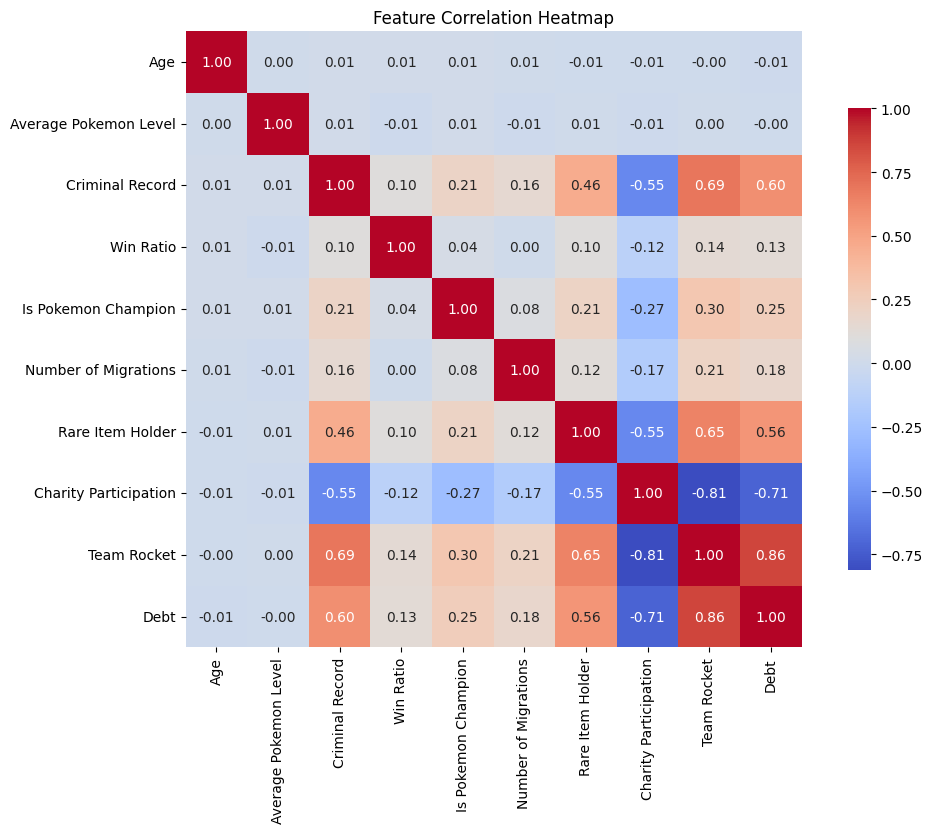

In [27]:


# Calculate correlation matrix
corr_matrix = data.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Generate a heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .75})

# Set title
plt.title("Feature Correlation Heatmap")

# Show plot
plt.show()

we are considering the protected features to be the ones that show up in the correlation matrix as higly correlated 
but
if we look at it from an ethical perspective, we can choose the features to be the ones that we expect to be a problem (being bad only because you have debt) 
in all, we need to decide if we choose based only on correlation because we don't want to assume, and we don't want the model to only decide based on those or if we choose them first and magically they are the higly correlated ones. 

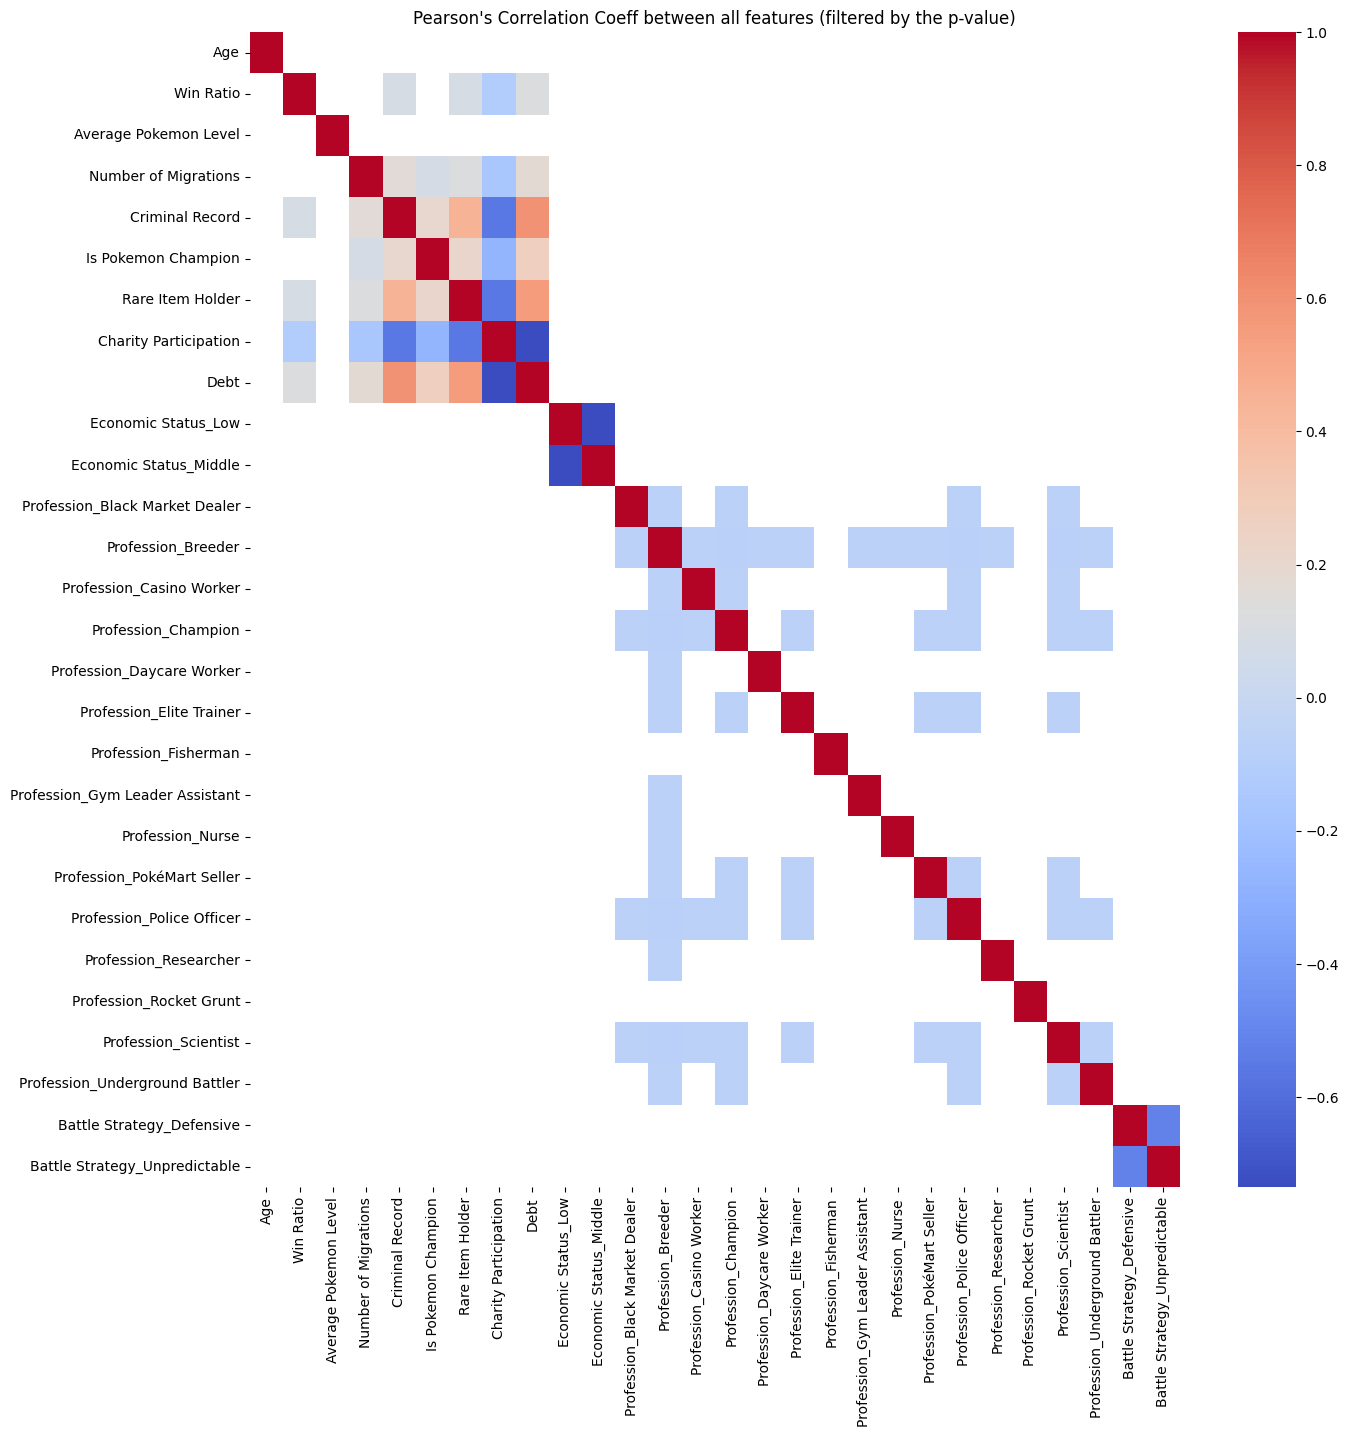

In [29]:
n_features = X_train_scaled.shape[1]

alpha = 0.05
corrected_alpha = alpha/ (n_features**2/2)

corr = np.zeros((n_features, n_features))
p = np.zeros((n_features, n_features))
for i in range(n_features):
    for j in range(n_features):
        corr[i,j], p[i,j] = pearsonr(X_train_scaled.iloc[:,i], X_train_scaled.iloc[:,j])
        if np.isnan(corr[i,j]):
            p[i,j] = 1


### Visualise full correlarion matrix
plt.figure(figsize=(15,15))
sns.heatmap(corr, cmap="coolwarm", xticklabels=X_train_scaled.columns, yticklabels=X_train_scaled.columns, mask= p > corrected_alpha) ## mask if p is higher
plt.title("Pearson's Correlation Coeff between all features (filtered by the p-value)")
plt.show()

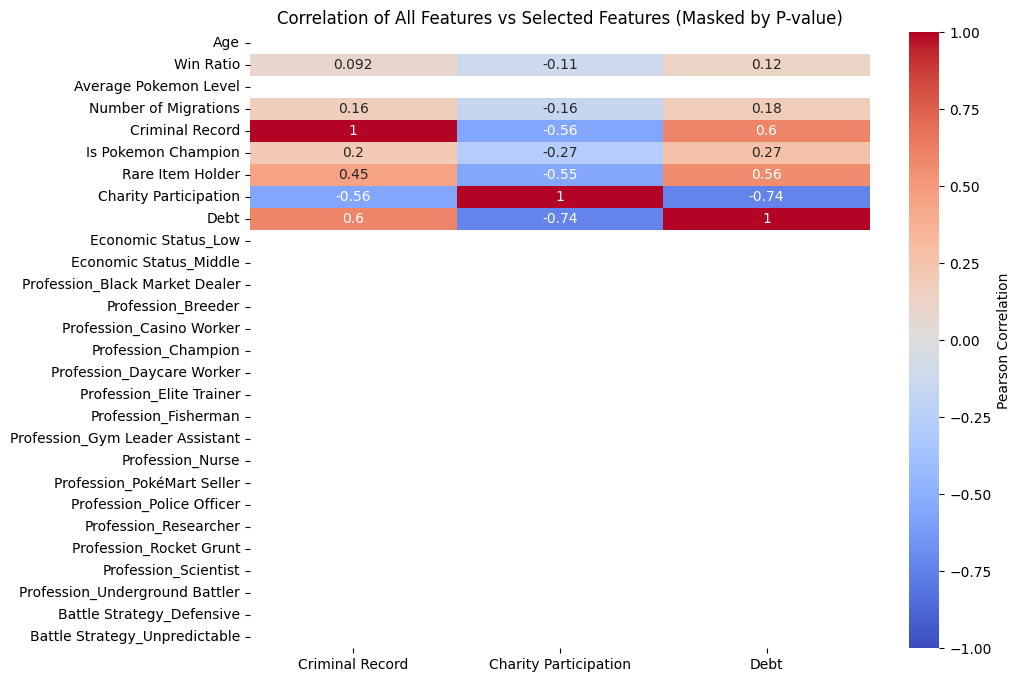

In [30]:
# Now select only columns 2, 4, 5 (and the corresponding rows)
selected_indices = [4, 7, 8] # criminal record, charity participation, debt

corr_selected = corr[:, selected_indices]
p_selected = p[:, selected_indices]

# Build the mask: True where p > corrected_alpha
mask = p_selected > corrected_alpha

# Get full row names and selected column names
row_names = X_train_scaled.columns
col_names = X_train_scaled.columns[selected_indices]

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_selected, 
    mask=mask,                  # Apply mask here
    xticklabels=col_names, 
    yticklabels=row_names,
    annot=True, 
    cmap="coolwarm", 
    vmin=-1, vmax=1,
    cbar_kws={"label": "Pearson Correlation"}
)
plt.title("Correlation of All Features vs Selected Features (Masked by P-value)")
plt.show()

# training

## logistic regression

### logistic basic 

In [33]:

logistic_model = LogisticRegression(max_iter=5000, penalty=None, C=0.8497534359086438, tol=1e-4, solver="saga")

# Fit the model
logistic_model.fit(X_train_scaled, y_train)

# Predictions
log_y_pred = logistic_model.predict(X_test_scaled)
log_y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

Setting penalty=None will ignore the C and l1_ratio parameters


In [34]:

log_accuracy = accuracy_score(y_test, log_y_pred)
log_accuracy

0.9950678175092479

In [58]:
balanced_accuracy_score(y_test, log_y_pred)

0.9874213836477987

In [ ]:
group_test_dict = {
    "Criminals": X_test_scaled["Criminal Record"] == 1.0, 
    "Non_Criminals": X_test_scaled["Criminal Record"] == 0.0,
    "Charity_givers": X_test_scaled["Charity Participation"] ==1.0,
    "Non_Charity_givers": X_test_scaled["Charity Participation"] ==1.0,
    "Big_Debt": X_test_scaled["Debt"] == 1.0,
    "Small_Debt": X_test_scaled["Debt"] == 0.0
}

In [63]:
group_test_dict

{'Criminals': 2015    False
 3965    False
 1397    False
 3840    False
 2416    False
         ...  
 848     False
 2882    False
 2862     True
 1351    False
 383     False
 Name: Criminal Record, Length: 811, dtype: bool,
 'Non_Criminals': 2015     True
 3965     True
 1397     True
 3840     True
 2416     True
         ...  
 848      True
 2882     True
 2862    False
 1351     True
 383      True
 Name: Criminal Record, Length: 811, dtype: bool,
 'Charity_givers': 2015     True
 3965     True
 1397     True
 3840     True
 2416     True
         ...  
 848      True
 2882     True
 2862    False
 1351     True
 383      True
 Name: Charity Participation, Length: 811, dtype: bool,
 'Non_Charity_givers': 2015     True
 3965     True
 1397     True
 3840     True
 2416     True
         ...  
 848      True
 2882     True
 2862    False
 1351     True
 383      True
 Name: Charity Participation, Length: 811, dtype: bool,
 'Big_Debt': 2015    False
 3965    False
 1397    False
 

In [60]:
# Calculate and print F1 Scores for each group
for group, group_idxs in group_test_dict.items():
    print(f'F1, {group}: {f1_score(y_test[group_idxs], log_y_pred[group_idxs]):.2f}')

# Calculate and print positive rates for each group
for group, group_idxs in group_test_dict.items():
    print(f'Positive Rate, {group}: {np.mean(log_y_pred[group_idxs]):.2f}')
    # Calculate and print positive rates for each group
for group, group_idxs in group_test_dict.items():
    print(f'Accuracy, {group}: {accuracy_score(y_test[group_idxs],log_y_pred[group_idxs]):.2f}')

for group, group_idxs in group_test_dict.items():
    print(f'Balanced Accuracy, {group}: {balanced_accuracy_score(y_test[group_idxs],log_y_pred[group_idxs]):.2f}')

F1, Criminals: 1.00
F1, Non_Criminals: 0.97
F1, Charity_givers: 0.96
F1, Non_Charity_givers: 0.96
F1, Big_Debt: 1.00
F1, Small_Debt: 0.96
Positive Rate, Criminals: 1.00
Positive Rate, Non_Criminals: 0.09
Positive Rate, Charity_givers: 0.06
Positive Rate, Non_Charity_givers: 0.06
Positive Rate, Big_Debt: 1.00
Positive Rate, Small_Debt: 0.06
Accuracy, Criminals: 1.00
Accuracy, Non_Criminals: 0.99
Accuracy, Charity_givers: 0.99
Accuracy, Non_Charity_givers: 0.99
Accuracy, Big_Debt: 1.00
Accuracy, Small_Debt: 0.99
Balanced Accuracy, Criminals: 1.00
Balanced Accuracy, Non_Criminals: 0.97
Balanced Accuracy, Charity_givers: 0.96
Balanced Accuracy, Non_Charity_givers: 0.96
Balanced Accuracy, Big_Debt: 1.00
Balanced Accuracy, Small_Debt: 0.96


A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.


### logistic without protected attributes

In [35]:
X_train_np = X_train_scaled.drop(columns= [ "Criminal Record", "Charity Participation", "Debt"], axis=1)
X_test_np = X_test_scaled.drop(columns= ["Criminal Record", "Charity Participation", "Debt"], axis=1)

In [37]:
X_train_np

,Age,Win Ratio,Average Pokemon Level,Number of Migrations,Is Pokemon Champion,Rare Item Holder,Economic Status_Low,Economic Status_Middle,Profession_Black Market Dealer,Profession_Breeder,...,Profession_Gym Leader Assistant,Profession_Nurse,Profession_PokéMart Seller,Profession_Police Officer,Profession_Researcher,Profession_Rocket Grunt,Profession_Scientist,Profession_Underground Battler,Battle Strategy_Defensive,Battle Strategy_Unpredictable
268,0.992205,-0.749783,1.441080,0.097882,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
16,-1.625422,0.035420,1.043146,-1.561240,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2445,-0.316608,-0.435702,-0.620945,-0.029742,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3181,0.992205,0.297154,1.404904,0.991256,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3711,0.195536,-0.697436,-0.548593,-0.284992,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,0.764586,-1.377946,-1.055056,0.225507,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3419,0.366251,-0.173968,1.441080,-1.688865,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2663,-0.145893,0.663582,0.283452,0.608382,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
169,0.764586,-1.220905,-0.005955,-0.923116,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [38]:
logistic_model2 = LogisticRegression(max_iter=5000, penalty=None, C=0.8497534359086438, tol=1e-4, solver="saga")

logistic_model2.fit(X_train_np, y_train)
y_hat= logistic_model2.predict(X_test_np)
log_accuracy_np = accuracy_score(y_test, y_hat)
log_accuracy_np

Setting penalty=None will ignore the C and l1_ratio parameters


0.906288532675709

In [31]:
logistic_model2.coef_

array([[ 0.03007223,  0.3842258 ,  0.01126061,  0.51471426,  0.04358193,
         0.01790936,  0.49320382,  0.10162152,  0.11768253, -0.30721247,
         0.15329431,  0.03492427,  0.01006458,  0.14585277,  0.20635225,
         0.2302735 ,  0.14180691,  0.12963606,  0.36369745,  0.17758301,
         0.21515403, -0.28579015, -0.19376988]])

In [61]:
# Calculate and print F1 Scores for each group
for group, group_idxs in group_test_dict.items():
    print(f'F1, {group}: {f1_score(y_test[group_idxs], y_hat[group_idxs]):.2f}')

# Calculate and print positive rates for each group
for group, group_idxs in group_test_dict.items():
    print(f'Positive Rate, {group}: {np.mean(y_hat[group_idxs]):.2f}')
    # Calculate and print positive rates for each group
for group, group_idxs in group_test_dict.items():
    print(f'Accuracy, {group}: {accuracy_score(y_test[group_idxs],y_hat[group_idxs]):.2f}')

F1, Criminals: 0.70
F1, Non_Criminals: 0.67
F1, Charity_givers: 0.61
F1, Non_Charity_givers: 0.61
F1, Big_Debt: 0.72
F1, Small_Debt: 0.60
Positive Rate, Criminals: 0.54
Positive Rate, Non_Criminals: 0.05
Positive Rate, Charity_givers: 0.03
Positive Rate, Non_Charity_givers: 0.03
Positive Rate, Big_Debt: 0.56
Positive Rate, Small_Debt: 0.03
Accuracy, Criminals: 0.54
Accuracy, Non_Criminals: 0.95
Accuracy, Charity_givers: 0.96
Accuracy, Non_Charity_givers: 0.96
Accuracy, Big_Debt: 0.56
Accuracy, Small_Debt: 0.96


# Fair PCA

In [40]:
X_train_scaled

,Age,Win Ratio,Average Pokemon Level,Number of Migrations,Criminal Record,Is Pokemon Champion,Rare Item Holder,Charity Participation,Debt,Economic Status_Low,...,Profession_Gym Leader Assistant,Profession_Nurse,Profession_PokéMart Seller,Profession_Police Officer,Profession_Researcher,Profession_Rocket Grunt,Profession_Scientist,Profession_Underground Battler,Battle Strategy_Defensive,Battle Strategy_Unpredictable
268,0.992205,-0.749783,1.441080,0.097882,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
16,-1.625422,0.035420,1.043146,-1.561240,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2445,-0.316608,-0.435702,-0.620945,-0.029742,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3181,0.992205,0.297154,1.404904,0.991256,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3711,0.195536,-0.697436,-0.548593,-0.284992,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,0.764586,-1.377946,-1.055056,0.225507,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3419,0.366251,-0.173968,1.441080,-1.688865,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2663,-0.145893,0.663582,0.283452,0.608382,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
169,0.764586,-1.220905,-0.005955,-0.923116,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [43]:
class FairPCA:
    def __init__(self, Xs, p_idxs, n_components):
        Xs = Xs.values
        self.fit(Xs, p_idxs, n_components)

    def fit(self, Xs, p_idxs, n_components):
        # Extract protected features
        Xs_p = Xs[:, p_idxs]

        # Compute projection matrix (U)
        Z = Xs_p
        #Z = Z - Z.mean(0) # Since we alredy standardised everything, there is not much sense in removing the mean
        R = scipy.linalg.null_space(Z.T @ Xs)
        eig_vals, L = scipy.linalg.eig(R.T @ Xs.T @ Xs @ R)
        self.U = R @ L[:, :n_components]

    def project(self, Xs):
        return Xs @ self.U
    
fair_pca = FairPCA(X_train_scaled, [4, 7, 8], 30)
Xs_train_debiased = fair_pca.project(X_train_scaled)
Xs_test_debiased = fair_pca.project(X_test_scaled)

In [44]:
X_train_p = X_train_scaled[["Criminal Record", "Charity Participation", "Debt"]]
X_test_p = X_test_scaled[["Criminal Record", "Charity Participation", "Debt"]]

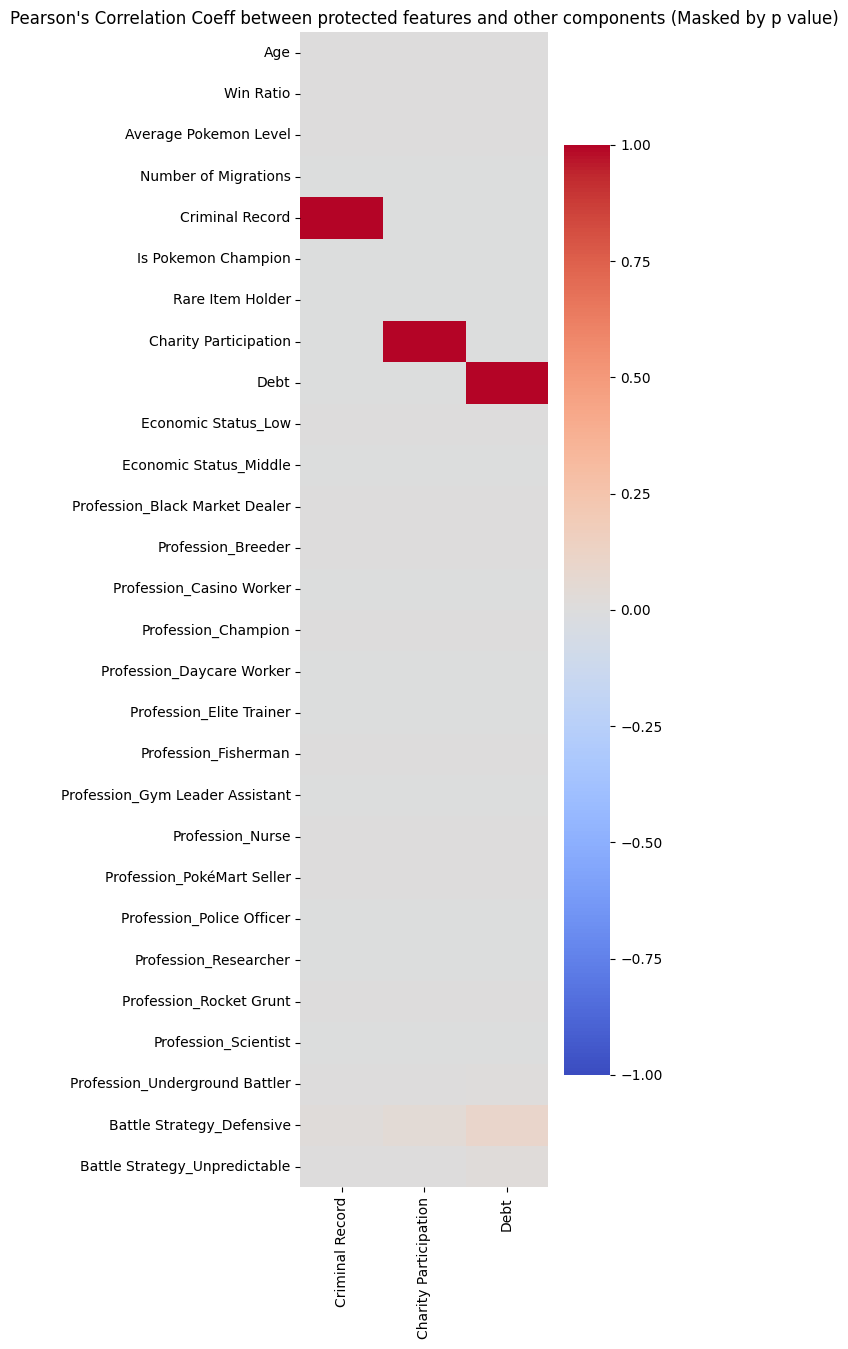

In [54]:
# Compute correlation matrix
Xs_train_debiased_p = np.concatenate([Xs_train_debiased, X_train_p], axis=1)
n_features = Xs_train_debiased_p.shape[1]
corr_ = np.zeros((n_features, n_features))
p_ = np.zeros((n_features, n_features))
for i in range(n_features):
    for j in range(n_features):
        corr_[i,j], p_[i,j] = pearsonr(Xs_train_debiased_p[:,i], Xs_train_debiased_p[:,j])
        corr_ = np.nan_to_num(corr_, 0)

# Plot correlations with protected features
plt.figure(figsize=(4,15))
sns.heatmap(corr_[:, [4, 7, 8]], cmap="coolwarm", 
            xticklabels=["Criminal Record", "Charity Participation", "Debt"], yticklabels=X_train_scaled.columns,
            vmin=-1, vmax=1)
plt.title("Pearson's Correlation Coeff between protected features and other components (Masked by p value)")
plt.show()

# Debiasing the model 

In [69]:
def sigmoid(x):
    """
    Compute the sigmoid function 
    f = 1/(1+exp(-beta^T * x))
    This function assumes as input that you have already multiplied beta and X together
    """
    return 1./(1 + np.exp(-x.astype(float)))

def logistic_loss(y_true, y_pred, eps = 1e-9):
    """
    Loss for the logistic regression, y_pred are probabilities
    """
    return -np.mean(y_true * np.log(y_pred + eps) + (1-y_true) * np.log(1-y_pred + eps))

def l2_loss(beta):
    """
    L2-Regularisation
    """
    return np.linalg.norm(beta,2)

def fair_loss_group(y, probs, groups, group_type):
    """
    Individual fairness Loss for gender
    """
    if group_type == "Criminal":
        n = y.shape[0]
        n1 = np.sum(groups == 0)
        n2 = np.sum(groups == 1)
    elif group_type == "Charity":
        n = y.shape[0]
        n1 = np.sum(groups == 0)
        n2 = np.sum(groups == 1)
    elif group_type == "Debt":
        n = y.shape[0]
        n1 = np.sum(groups == 0)
        n2 = np.sum(groups == 1)
    #print(n, n1, n2)
    
    ## Solution with numpy
    equal_pairs = np.argwhere(y[np.newaxis, :] == y[:, np.newaxis]) ### Check if labels are the same, distance is 1 if y[i] == y[j] and 0 if y[i] != y[j]
    equal_pairs = equal_pairs[np.where(equal_pairs[:,0] != equal_pairs[:,1])] ### Remove the pairs where items are compared to themselves
    
    
    #diff_groups = (groups[equal_pairs[:,0]] != groups[equal_pairs[:,1]]).astype(int) ### Find pairs where groups are different
    diff_groups = (groups.iloc[equal_pairs[:,0]].to_numpy() != groups.iloc[equal_pairs[:,1]].to_numpy()).astype(int)

    diff_probs = probs.iloc[equal_pairs[:,0]].to_numpy() - probs.iloc[equal_pairs[:,1]].to_numpy()
   
    
    cost = diff_groups.dot(diff_probs)  # Ensures correct dot product shape
    cost /= (n1*n2)
    
    return cost**2

def compute_cost(beta, X, y, groups, group_type, _lambda, _gamma):
    # Compute predicted probs
    probs = sigmoid(X.dot(beta).astype(float))
    # Compute joint loss
    loss = logistic_loss(y, probs) + _lambda * fair_loss_group(y, probs, groups, group_type) + _gamma * l2_loss(beta[1:])
    return loss

def compute_gradients(beta, X, y, groups, group_type, _lambda, _gamma):
    """
    Calculate the gradient - used for finding the best beta values
    """
    # Start with empty gradient
    grad = np.zeros(beta.shape)
    
    m = len(X) # Number of training samples
    
    # Calculate the probs
    probs = sigmoid(X.dot(beta).astype(float))
    
    # Calculate gradients for each beta value
    for j in range(len(grad)):
        if j == 0: ### We do not want to regularize the intercept
            grad[j] = (1/m) * (probs-y).dot(X.iloc[:,j])
        else:
            grad[j] = (1/m) * (probs-y).dot(X.iloc[:,j]) + (2*_gamma)*beta[j]
        
    return grad

criminal record

In [70]:
# criminals 
compute_cost(
    beta = np.random.rand(X_train_scaled.shape[1]),
    X = X_train_scaled, 
    y = y_train,
    groups = X_train_scaled["Criminal Record"], 
    group_type = "Criminal",
    _gamma = 1, 
    _lambda = 0.1
)

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.


5.301677245834174

In [ ]:
# Set seed and define params
beta = np.random.rand(X_train_scaled.shape[1])
lambda_ = 0.1
gamma_ = 1e-5 

# Run optimization
result_criminal, _, _ = opt.fmin_tnc(
    func=compute_cost,
    x0=beta,
    fprime=compute_gradients,
    approx_grad=False,
    maxfun = 500,
    args = (
        X_train_scaled, 
        y_train,
        X_train_scaled["Criminal Record"],
        "Criminal",
        lambda_, 
        gamma_
    ),
    xtol=1e-7,
    ftol=1e-5
)

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  NIT   NF   F                       GTG
    0    1  1.437304951612201E+00   6.20449392E-01
    1    4  3.772529613385459E-01   4.70369859E-02
    2    8  1.232189925110090E-01   6.18901059E-03
tnc: stepmx = 1000
    3   13  4.264051083237441E-02   1.63567896E-04
tnc: fscale = 56.6494
    4   19  2.819099031716547E-02   2.18935532E-05
    5   25  2.592093931511753E-02   2.80429399E-06
    6   30  2.403185887694431E-02   1.13596155E-06
    7   35  2.288216120370860E-02   3.89501569E-07
    8   42  2.218644146186746E-02   7.20995871E-08
tnc: fscale = 2538.26
    9   49  2.216770711272422E-02   5.01358072E-09
tnc: |fn-fn-1] = 1.46648e-07 -> convergence
   10   72  2.216756046423880E-02   2.49069130E-09
tnc: Converged (|f_n-f_(n-1)| ~= 0)


In [ ]:
y_pred_fair_g = np.array([True if x >=0.5 else False for x in sigmoid(result_g @ X_test_small.T)])

charity participation

In [ ]:
# charity
compute_cost(
    beta = np.random.rand(X_train_scaled.shape[1]),
    X = X_train_scaled, 
    y = y_train,
    groups = X_train_scaled["Charity Participation"], 
    group_type = "Charity",
    _gamma = 1, 
    _lambda = 0.1
)

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.


4.540666391438469

In [76]:
# Set seed and define params
beta = np.random.rand(X_train_scaled.shape[1])
lambda_ = 0.1
gamma_ = 1e-5 

# Run optimization
result_charity, _, _ = opt.fmin_tnc(
    func=compute_cost,
    x0=beta,
    fprime=compute_gradients,
    approx_grad=False,
    maxfun = 500,
    args = (
        X_train_scaled, 
        y_train,
        X_train_scaled["Charity Participation"],
        "Charity",
        lambda_, 
        gamma_
    ),
    xtol=1e-7,
    ftol=1e-5
)

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  NIT   NF   F                       GTG
    0    1  1.858933614571339E+00   7.19458123E-01
    1    5  4.803305387485086E-01   7.27869420E-02
    2   10  2.066227464051249E-01   1.50512382E-02
    3   15  1.163404003744765E-01   3.06177098E-03
    4   19  5.793633635361356E-02   3.13796556E-04
tnc: fscale = 35.2172
    5   27  2.615777912384998E-02   2.58504757E-05
    6   32  2.424587602970822E-02   2.85895657E-06
    7   39  2.267014086595014E-02   4.46941738E-07
tnc: fscale = 928.726
    8   46  2.240190828994231E-02   2.77469471E-08
    9   51  2.217294738241522E-02   9.81748691E-10
tnc: fscale = 20805.2
    9  100  2.217294738241522E-02   9.81748691E-10
tnc: Linear search failed


debt to kanto

In [77]:
# debt 
compute_cost(
    beta = np.random.rand(X_train_scaled.shape[1]),
    X = X_train_scaled, 
    y = y_train,
    groups = X_train_scaled["Debt"], 
    group_type = "Debt",
    _gamma = 1, 
    _lambda = 0.1
)

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.


5.027915262683411

In [78]:
# Set seed and define params
beta = np.random.rand(X_train_scaled.shape[1])
lambda_ = 0.1
gamma_ = 1e-5 

# Run optimization
result_debt, _, _ = opt.fmin_tnc(
    func=compute_cost,
    x0=beta,
    fprime=compute_gradients,
    approx_grad=False,
    maxfun = 500,
    args = (
        X_train_scaled, 
        y_train,
        X_train_scaled["Debt"],
        "Debt",
        lambda_, 
        gamma_
    ),
    xtol=1e-7,
    ftol=1e-5
)

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  NIT   NF   F                       GTG
    0    1  1.751190233187997E+00   7.42284253E-01
    1    5  3.308730817539219E-01   4.85620082E-02
    2    9  1.359482901553258E-01   8.08107384E-03
    3   15  4.716956926415716E-02   1.95891706E-04
tnc: fscale = 43.8519
    4   22  3.202787940393769E-02   1.46554092E-05
    5   29  2.660808013368956E-02   9.09646123E-06
    6   37  2.370333122959269E-02   2.54971591E-06
    7   45  2.241273026605130E-02   1.67164644E-07
tnc: fscale = 1504.17
    8   54  2.218495612516570E-02   3.77644584E-09
    9   57  2.216097691030912E-02   9.27851233E-10
tnc: |fn-fn-1] = 1.60384e-06 -> convergence
   10   61  2.215937306679867E-02   7.85140545E-11
tnc: Converged (|f_n-f_(n-1)| ~= 0)


## SHAP

using the shap library to see which are the features that influence decisions the most


In [25]:
features = X_train_scaled.columns

In [26]:
explainer = shap.Explainer(logistic_model, X_train_scaled, feature_names=features)
shap_values_log = explainer(X_test_scaled)

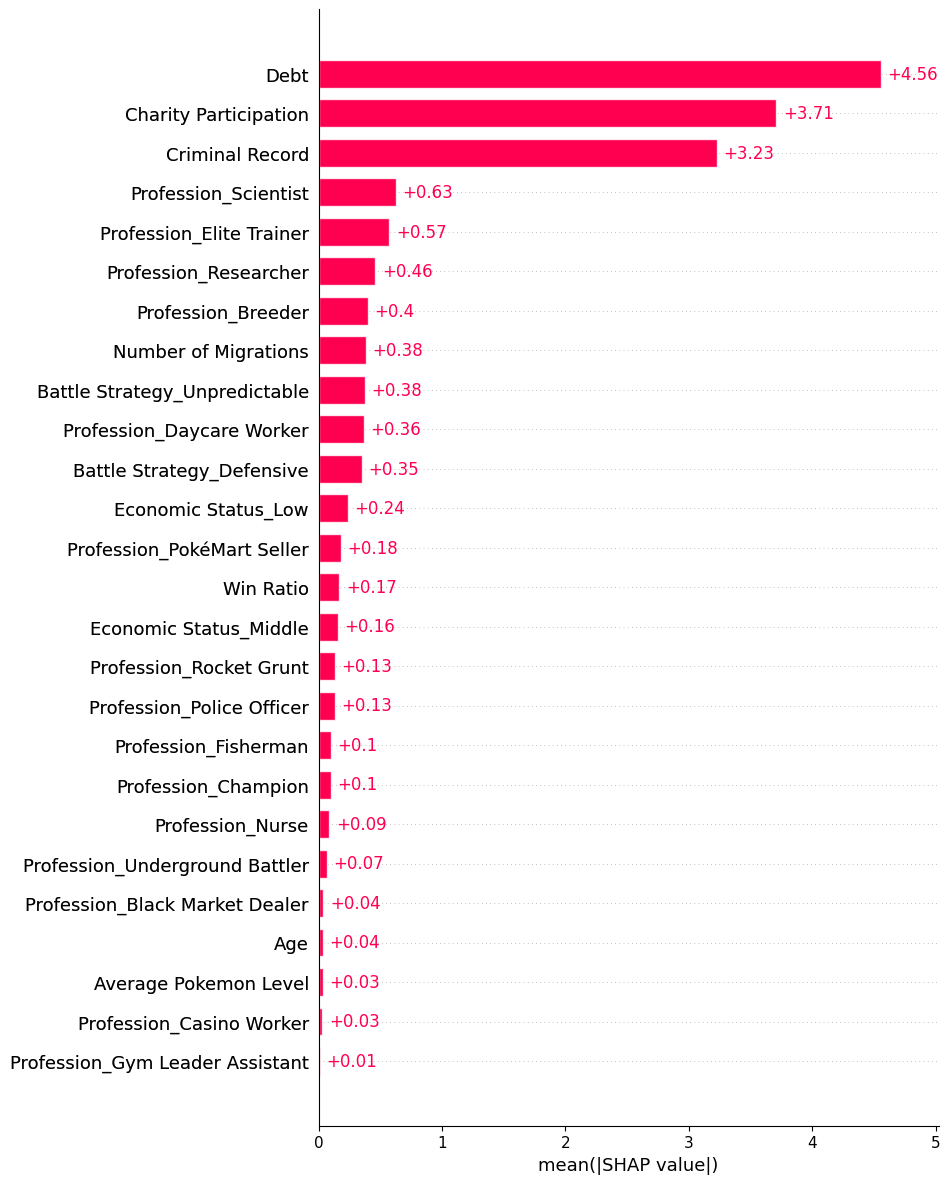

In [27]:
shap.plots.bar(shap_values_log, max_display=33)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


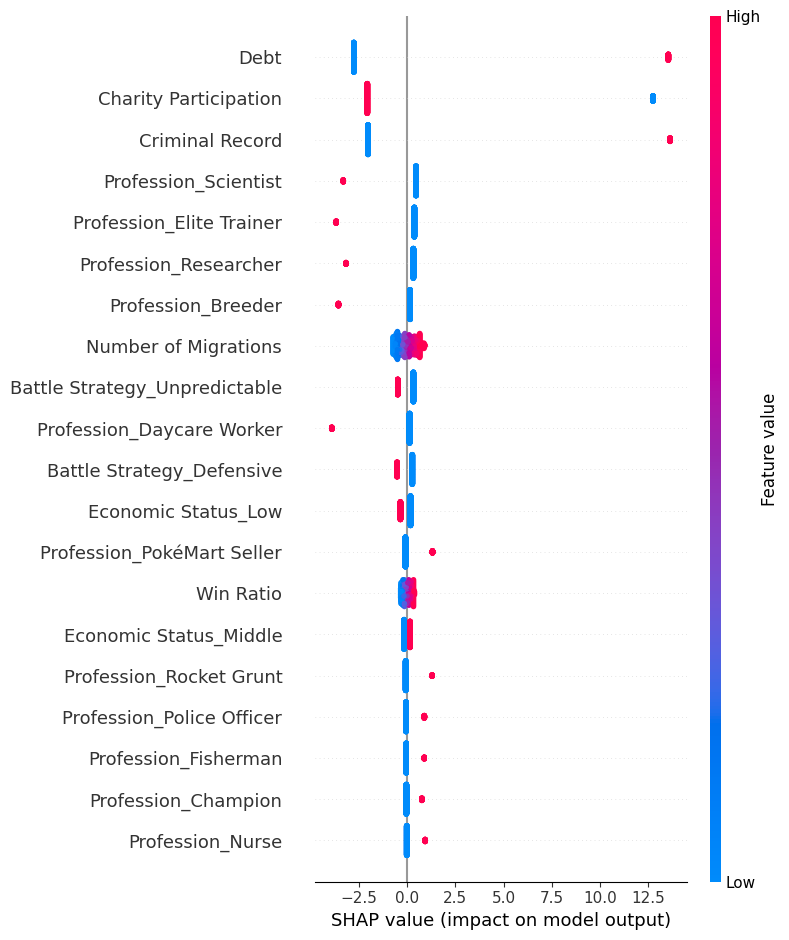

In [28]:
shap.summary_plot(shap_values_log, X_test_scaled)